# Visualize JAX Function Samplers

This notebook demonstrates how to use and visualize the JAX-based function samplers defined in your project.

## 1. Setup and Imports

Import necessary libraries and configure the path to your project source code. We also enable `autoreload` so that changes made to your `.py` files are automatically picked up when you re-run cells.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple, Tuple, Dict, List

# IMPORTANT: Set this to the correct root directory of your project
# Use an absolute path for reliability
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax" # Use the path you provided

if not os.path.isdir(root_dir):
    print(f"Error: Directory not found: {root_dir}")
    print("Please update the 'root_dir' variable to the correct path.")
else:
    if root_dir not in sys.path:
        sys.path.append(root_dir)
        print(f"Added {root_dir} to sys.path")

# Attempt to import your sampler functions
try:
    # Assuming your functions are in this specific module path
    from tasks.envs.jax_env.jax_function_samplers import (
        initialize_sampler,
        compute_y_sampler,
        # Also import EnvParams if it's defined there, otherwise define it below
        # EnvParams
    )
    print("Successfully imported sampler functions.")
except ImportError as e:
    print(f"Error importing sampler functions: {e}")
    print("Please ensure 'root_dir' is correct and the module path exists:")
    print("src.tasks.envs.function_envs.jax_samplers.jax_function_samplers")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

# --- Define EnvParams if not imported ---
# (Make sure this matches the definition expected by your functions)
class EnvParams(NamedTuple):
    action_dim: int
    x_range: Tuple[float, float]
    # Add other default parameters needed by your initializers
    poly_degree: int = 2
    poly_c_bounds: Tuple[float, float] = (5.0, 20.0)
    poly_weight_bounds: Tuple[float, float] = (0.5, 2.0)
    poly_optimum_range_factor: float = 0.9
    ackley_a_bounds: Tuple[float, float] = (15.0, 20.0)
    ackley_b_bounds: Tuple[float, float] = (0.1, 0.2)
    ackley_c_bounds: Tuple[float, float] = (2 * jnp.pi, 2 * jnp.pi)
    ackley_optimum_range_factor: float = 0.6

# Configure Matplotlib for inline plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-darkgrid')

Added c:\Users\jimvo\Documents\Recurrent-PPO-Jax to sys.path
Successfully imported sampler functions.


## 2. Visualize a Single Sampled Function (1D)

Let's initialize one instance of a function (e.g., Polynomial, index 1) and plot it. We'll focus on 1D functions (`action_dim=1`) for easy visualization.

--- Initialized Sampler Parameters ---
  common: {'action_dim': Array(1, dtype=int32, weak_type=True), 'max_y': Array(0., dtype=float32, weak_type=True), 'min_y': Array(-13.1333475, dtype=float32), 'optimum_point': Array([-0.6659274], dtype=float32), 'type_index': Array(0, dtype=int32, weak_type=True)}
  specific: {'ackley': {'a': Array(17.651304, dtype=float32), 'b': Array(0.17276643, dtype=float32), 'c': Array(6.2831855, dtype=float32)}, 'poly': {'c': Array(nan, dtype=float32, weak_type=True), 'degree': Array(0, dtype=int32, weak_type=True), 'weights': Array([nan], dtype=float32), 'x_max': Array([nan], dtype=float32)}}


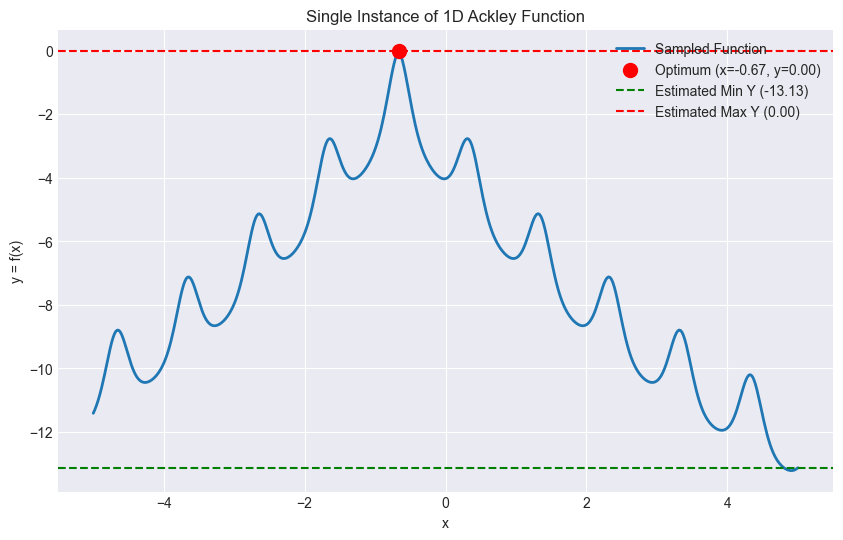

In [6]:
# --- Configuration ---
sampler_index_to_plot = 0  # 0 for Ackley, 1 for Polynomial
action_dimension = 1
x_min, x_max = -5.0, 5.0
num_points = 500 # Number of points for plotting the function shape

# --- Environment Parameters ---
env_params = EnvParams(action_dim=action_dimension, x_range=(x_min, x_max))

# --- Initialize Sampler ---
key = jax.random.PRNGKey(42) # Use a fixed key for reproducibility
sampler_params = initialize_sampler(key, sampler_index_to_plot, env_params) #this line still crashes

print("--- Initialized Sampler Parameters ---")
# Pretty print the dictionary contents
for k, v in sampler_params.items():
    print(f"  {k}: {v}")

# --- Generate Data for Plotting ---
# Create a range of x values for plotting
x_plot = jnp.linspace(x_min, x_max, num_points).reshape(-1, action_dimension)

# # Compute y values using vmap for efficiency
# # Define a function that computes y for a single x using the initialized params
compute_single_y_jit = jax.jit(lambda x: compute_y_sampler(x, sampler_params, env_params))
# Map the JITted function over all x values
y_plot = jax.vmap(compute_single_y_jit)(x_plot)

compute_batch_y = jax.vmap(lambda x: compute_y_sampler(x, sampler_params, env_params))
# JIT the whole vmapped operation
compute_batch_y_jit = jax.jit(compute_batch_y)
y_plot = compute_batch_y_jit(x_plot)

# --- Plotting ---
plt.figure()
plt.plot(x_plot.flatten(), y_plot.flatten(), label='Sampled Function', linewidth=2)

# Highlight Min/Max and Optimum
# for k in sampler_params.keys():
#     print(k["commmon"])

opt_x = sampler_params["common"]['optimum_point']
max_y = sampler_params["common"]['max_y']
min_y = sampler_params["common"]['min_y']

plt.scatter([opt_x], [max_y], color='red', s=100, zorder=5, label=f'Optimum (x={opt_x[0]:.2f}, y={max_y:.2f})')
plt.axhline(min_y, color='green', linestyle='--', label=f'Estimated Min Y ({min_y:.2f})')
plt.axhline(max_y, color='red', linestyle='--', label=f'Estimated Max Y ({max_y:.2f})')

# Add labels and title
func_name = 'Polynomial' if sampler_index_to_plot == 1 else 'Ackley' if sampler_index_to_plot == 0 else f'Sampler {sampler_index_to_plot}'
plt.title(f'Single Instance of 1D {func_name} Function')
plt.xlabel('x')
plt.ylabel('y = f(x)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Visualize Multiple Sampled Functions (1D)

Now, let's sample multiple functions (e.g., 5 Ackley functions, index 0) and plot them on the same graph to see the variety generated by the sampler.

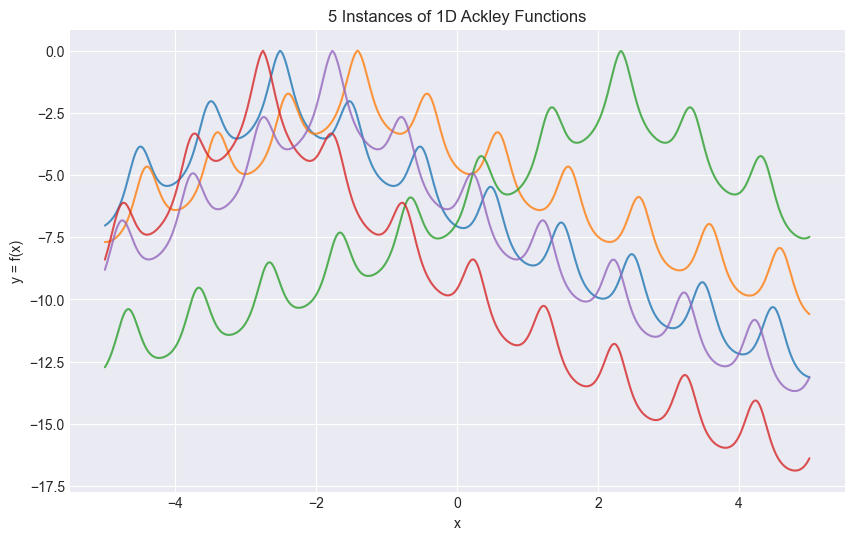

In [5]:
# --- Configuration ---
sampler_index_to_plot = 0  # 0 for Ackley, 1 for Polynomial
num_functions_to_plot = 5
action_dimension = 1
x_min, x_max = -5.0, 5.0
num_points = 500 # Number of points for plotting the function shape

# --- Environment Parameters ---
env_params = EnvParams(action_dim=action_dimension, x_range=(x_min, x_max))

# --- Generate Data for Plotting ---
key = jax.random.PRNGKey(99) # Starting key
x_plot = jnp.linspace(x_min, x_max, num_points).reshape(-1, action_dimension)

plt.figure()

for i in range(num_functions_to_plot):
    # Get a new key for each function instance
    key, subkey = jax.random.split(key)

    # Initialize the sampler
    sampler_params = initialize_sampler(subkey, sampler_index_to_plot, env_params)

    # Compute y values for this specific function instance
    compute_single_y = lambda x: compute_y_sampler(x, sampler_params, env_params)
    y_plot = jax.vmap(compute_single_y)(x_plot)

    # Plot this function instance
    plt.plot(x_plot.flatten(), y_plot.flatten(), label=f'Instance {i+1}', alpha=0.8)

# Add labels and title
func_name = 'Polynomial' if sampler_index_to_plot == 1 else 'Ackley' if sampler_index_to_plot == 0 else f'Sampler {sampler_index_to_plot}'
plt.title(f'{num_functions_to_plot} Instances of 1D {func_name} Functions')
plt.xlabel('x')
plt.ylabel('y = f(x)')
# plt.legend() # Legend might get crowded, optional
plt.grid(True)
plt.show()

## 4. Notes on 2D Visualization (Optional)

Visualizing 2D functions (`action_dim=2`) requires different plotting techniques:

1.  **Create a grid:** Use `jnp.meshgrid` to create X and Y coordinate matrices over the `x_range`.
2.  **Combine coordinates:** Stack the X and Y matrices to form input points `(x, y)` suitable for `compute_y_sampler` (shape `(num_points*num_points, 2)`).
3.  **Compute Z values:** Calculate the function output `Z` for all points on the grid.
4.  **Reshape Z:** Reshape the output `Z` back into a 2D grid matching the X and Y shapes.
5.  **Plot:** Use `plt.contourf` (filled contour) or `plt.imshow` (image plot) to visualize the 2D function landscape. You can also add the optimum point using `plt.scatter`.